In [1]:
!pip -q install xgboost kagglehub
import os, glob, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import wilcoxon, loguniform, randint, uniform, t as tdist
from sklearn.base import clone
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RepeatedStratifiedKFold, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, matthews_corrcoef)
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")
SEED = 42; np.random.seed(SEED)
os.makedirs("results", exist_ok=True)

def load_data():
    if os.path.exists("heart.csv"):
        return pd.read_csv("heart.csv")
    try:
        import kagglehub
        p = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
        return pd.read_csv(glob.glob(os.path.join(p, "*.csv"))[0])
    except Exception as e:
        print("Auto-download failed, please upload heart.csv ->", e)
        from google.colab import files
        return pd.read_csv(list(files.upload().keys())[0])

df = load_data()
FEATS = [c for c in df.columns if c != "target"]
print(df.shape, "| missing:", df.isna().sum().sum())
print(df["target"].value_counts())
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup} ({n_dup/len(df):.1%}) -> unique rows: {len(df)-n_dup}")
df_u = df.drop_duplicates().reset_index(drop=True)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
(1025, 14) | missing: 0
target
1    526
0    499
Name: count, dtype: int64
Duplicate rows: 723 (70.5%) -> unique rows: 302


In [2]:
COLS = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

def metrics_from(y, pred, prob):
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return dict(Accuracy=accuracy_score(y, pred), Precision=precision_score(y, pred),
                Recall=recall_score(y, pred), F1=f1_score(y, pred),
                AUC=roc_auc_score(y, prob), Specificity=tn/(tn+fp),
                MCC=matthews_corrcoef(y, pred))

def base_models(seed):   # paper gives no params -> sklearn/xgboost defaults (assumption)
    return {"LR": LogisticRegression(max_iter=1000, random_state=seed),
            "DT": DecisionTreeClassifier(random_state=seed),
            "RF": RandomForestClassifier(random_state=seed),
            "XGB": XGBClassifier(eval_metric="logloss", random_state=seed),
            "NB": GaussianNB(),
            "KNN": KNeighborsClassifier()}

def make_stack(seed):    # paper: 5-fold stacking, meta-learner unspecified -> LR (assumption)
    return StackingClassifier(estimators=list(base_models(seed).items()),
                              final_estimator=LogisticRegression(max_iter=1000),
                              cv=5, stack_method="auto")

# Table 11 of the paper (precision/recall/F1 are for class 1)
PAPER = {"LR":  dict(Accuracy=.8439, Precision=.8196, Recall=.9090, F1=.8620, AUC=.9204),
         "DT":  dict(Accuracy=.9268, Precision=.9702, Recall=.8909, F1=.9289, AUC=.9702),
         "RF":  dict(Accuracy=.9268, Precision=.9130, Recall=.9545, F1=.9333, AUC=.9734),
         "XGB": dict(Accuracy=.9073, Precision=.9174, Recall=.9090, F1=.9132, AUC=.983),
         "NB":  dict(Accuracy=.8439, Precision=.8250, Recall=.9000, F1=.8608, AUC=.9185),
         "KNN": dict(Accuracy=.8585, Precision=.8648, Recall=.8727, F1=.8687, AUC=.9304),
         "Stacking": dict(Accuracy=.9853, Precision=1.0, Recall=.9727, F1=.9861, AUC=.988)}

def run_protocol(data, seed):
    """Paper protocol: standardise ALL features first, then random 80/20 split (no stratify)."""
    X = StandardScaler().fit_transform(data[FEATS].values); y = data["target"].values
    itr, ite = train_test_split(np.arange(len(data)), test_size=0.2, random_state=seed)
    models = base_models(seed); models["Stacking"] = make_stack(seed)
    rows, det = [], {}
    for n, m in models.items():
        m.fit(X[itr], y[itr]); pred = m.predict(X[ite]); prob = m.predict_proba(X[ite])[:, 1]
        r = metrics_from(y[ite], pred, prob); r.update(Model=n, seed=seed); rows.append(r)
        det[n] = (y[ite], pred, prob)
    return pd.DataFrame(rows), det

,Accuracy,Precision,Recall,F1,AUC,Accuracy_paper,Precision_paper,Recall_paper,F1_paper,AUC_paper
Model,,,,,,,,,,
LR,0.7951,0.7563,0.8738,0.8108,0.8790,0.8439,0.8196,0.9090,0.8620,0.9204
DT,0.9854,1.0000,0.9709,0.9852,0.9854,0.9268,0.9702,0.8909,0.9289,0.9702
RF,0.9854,1.0000,0.9709,0.9852,1.0000,0.9268,0.9130,0.9545,0.9333,0.9734
XGB,0.9854,1.0000,0.9709,0.9852,0.9894,0.9073,0.9174,0.9090,0.9132,0.9830
NB,0.8000,0.7541,0.8932,0.8178,0.8706,0.8439,0.8250,0.9000,0.8608,0.9185
KNN,0.8341,0.8000,0.8932,0.8440,0.9508,0.8585,0.8648,0.8727,0.8687,0.9304
Stacking,0.9854,1.0000,0.9709,0.9852,1.0000,0.9853,1.0000,0.9727,0.9861,0.9880


,Specificity,MCC
Model,,
LR,0.7157,0.5973
DT,1.0000,0.9712
RF,1.0000,0.9712
XGB,1.0000,0.9712
NB,0.7059,0.6102
KNN,0.7745,0.6727
Stacking,1.0000,0.9712


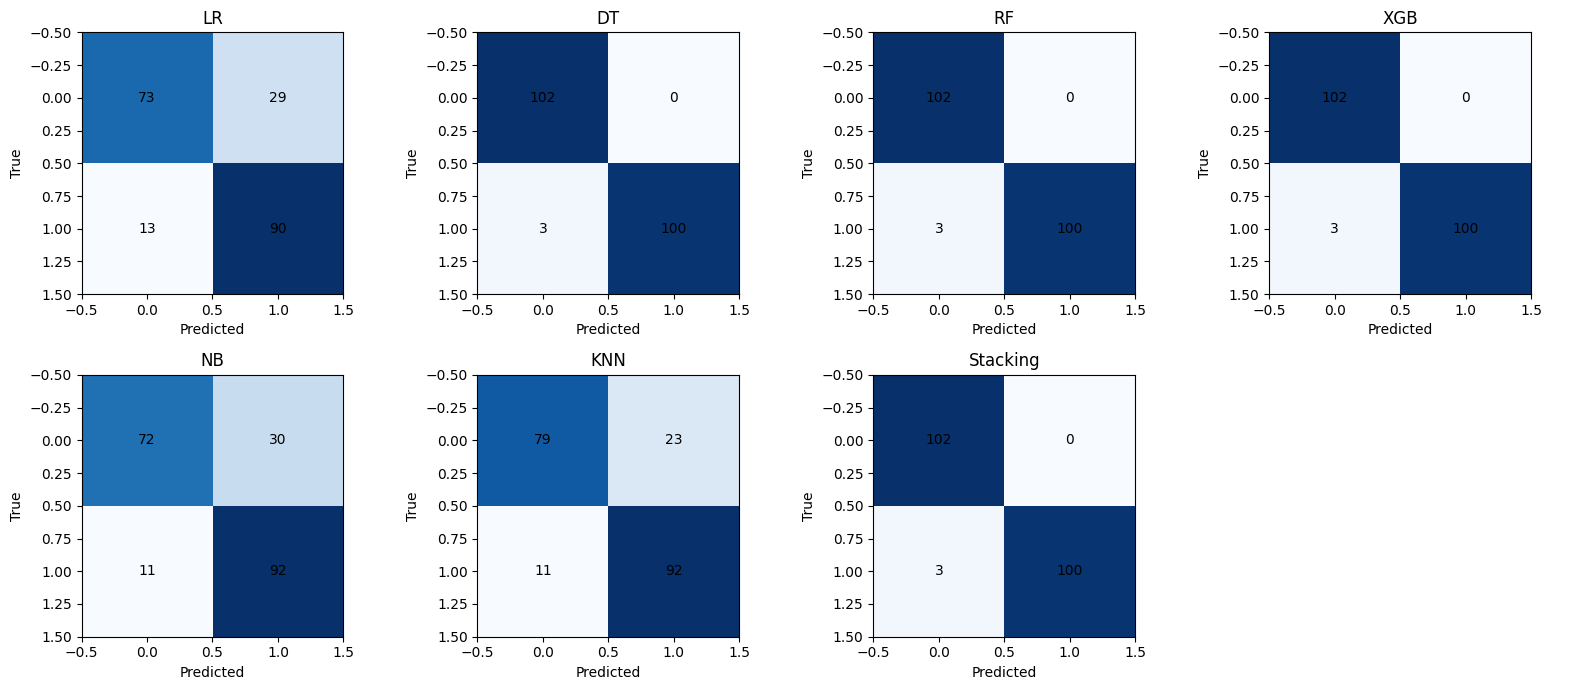

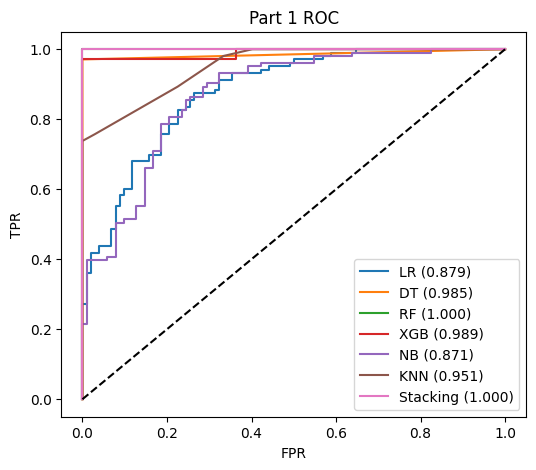

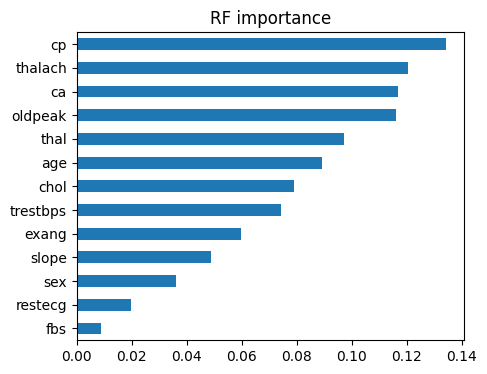

In [3]:
res, det = run_protocol(df, SEED)
mine = res.set_index("Model")
cmp = mine[COLS].join(pd.DataFrame(PAPER).T[COLS], rsuffix="_paper").round(4)
display(cmp); cmp.to_csv("results/part1_repro_vs_paper.csv")
display(mine[["Specificity", "MCC"]].round(4))   # correctly computed (paper's are mislabelled)

# Confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (n, (y, p, _)) in zip(axes.ravel(), det.items()):
    cm = confusion_matrix(y, p); ax.imshow(cm, cmap="Blues"); ax.set_title(n)
    for i in range(2):
        for j in range(2): ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
axes.ravel()[-1].axis("off"); plt.tight_layout(); plt.savefig("results/p1_confusion.png", dpi=150); plt.show()

# ROC (from probabilities, not hard labels)
plt.figure(figsize=(6, 5))
for n, (y, _, s) in det.items():
    f, t_, _ = roc_curve(y, s); plt.plot(f, t_, label=f"{n} ({roc_auc_score(y, s):.3f})")
plt.plot([0, 1], [0, 1], "k--"); plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Part 1 ROC"); plt.savefig("results/p1_roc.png", dpi=150); plt.show()

# RF feature importance (paper Fig. 2)
rf = RandomForestClassifier(random_state=SEED).fit(StandardScaler().fit_transform(df[FEATS]), df["target"])
pd.Series(rf.feature_importances_, FEATS).sort_values().plot.barh(figsize=(5, 4), title="RF importance")
plt.savefig("results/p1_importance.png", dpi=150); plt.show()

In [4]:
seeds = range(20)
full_runs  = pd.concat([run_protocol(df,   s)[0] for s in seeds])
dedup_runs = pd.concat([run_protocol(df_u, s)[0] for s in seeds])
fmt = lambda d: d.groupby("Model")[COLS].agg(["mean", "std"]).round(4)
print("FULL data (1025 rows, as in paper), 20 random splits"); display(fmt(full_runs))
print("DEDUPLICATED data, same protocol");                   display(fmt(dedup_runs))

def overlap(data, seed):   # share of test rows that have an exact copy in train
    itr, ite = train_test_split(np.arange(len(data)), test_size=0.2, random_state=seed)
    X = data[FEATS].values; tr = set(map(tuple, X[itr]))
    return np.mean([tuple(r) in tr for r in X[ite]])
print(f"Mean test rows duplicated in train: {np.mean([overlap(df, s) for s in seeds]):.1%}")

FULL data (1025 rows, as in paper), 20 random splits


Accuracy         Precision          Recall              F1          \
             mean     std      mean     std    mean     std    mean     std   
Model                                                                         
DT         0.9939  0.0113    0.9910  0.0170  0.9971  0.0090  0.9940  0.0111   
KNN        0.8493  0.0288    0.8546  0.0514  0.8541  0.0304  0.8533  0.0291   
LR         0.8434  0.0196    0.8165  0.0407  0.8988  0.0232  0.8548  0.0204   
NB         0.8283  0.0250    0.8056  0.0378  0.8776  0.0262  0.8396  0.0270   
RF         0.9971  0.0077    0.9970  0.0091  0.9972  0.0085  0.9971  0.0076   
Stacking   0.9956  0.0107    0.9942  0.0151  0.9972  0.0085  0.9957  0.0105   
XGB        0.9963  0.0081    0.9943  0.0148  0.9987  0.0058  0.9964  0.0079   

             AUC          
            mean     std  
Model                     
DT        0.9939  0.0113  
KNN       0.9574  0.0109  
LR        0.9196  0.0124  
NB        0.9067  0.0174  
RF        0.9999  0.0004  
Stacking  0.9997  0.0008  
XGB       0.9999  0.0004

DEDUPLICATED data, same protocol


Accuracy         Precision          Recall              F1          \
             mean     std      mean     std    mean     std    mean     std   
Model                                                                         
DT         0.7664  0.0542    0.7966  0.0643  0.7737  0.0836  0.7818  0.0549   
KNN        0.8197  0.0470    0.8200  0.0558  0.8639  0.0517  0.8398  0.0396   
LR         0.8320  0.0454    0.8307  0.0550  0.8749  0.0644  0.8501  0.0410   
NB         0.8131  0.0392    0.8237  0.0484  0.8413  0.0664  0.8302  0.0381   
RF         0.8197  0.0560    0.8238  0.0552  0.8544  0.0663  0.8375  0.0517   
Stacking   0.8254  0.0446    0.8307  0.0540  0.8592  0.0653  0.8426  0.0417   
XGB        0.8057  0.0598    0.8133  0.0587  0.8381  0.0763  0.8239  0.0574   

             AUC          
            mean     std  
Model                     
DT        0.7650  0.0558  
KNN       0.8882  0.0288  
LR        0.9032  0.0340  
NB        0.8945  0.0370  
RF        0.9023  0.0278  
Stacking  0.9071  0.0288  
XGB       0.8797  0.0318

Mean test rows duplicated in train: 96.6%


In [5]:
N_SPLITS, N_REPEATS, N_ITER = 5, 3, 8     # lower N_REPEATS/N_ITER if Colab is slow (~10-30 min as is)
NUM, BIN, CAT = ["age","trestbps","chol","thalach","oldpeak"], ["sex","fbs","exang"], ["cp","restecg","slope","thal","ca"]
NUM_FE = ["max_hr_utilisation", "oldpeak_flat_down", "metabolic_risk", "ischemia_score"]

def engineer(X):   # row-wise, stateless -> no leakage. Assumes UCI coding (slope 2 = upsloping)
    X = X.copy()
    X["max_hr_utilisation"] = X["thalach"] / (220 - X["age"])
    X["oldpeak_flat_down"] = X["oldpeak"] * (X["slope"] != 2).astype(int)
    X["metabolic_risk"]    = (X["trestbps"] >= 140).astype(int) + (X["chol"] >= 240).astype(int) + X["fbs"]
    X["ischemia_score"]    = X["exang"] + (X["oldpeak"] >= 1).astype(int) + (X["ca"] > 0).astype(int)
    return X

def make_prep():
    return ColumnTransformer([("num", StandardScaler(), NUM + NUM_FE), ("bin", "passthrough", BIN),
                              ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)])

SPACES = {
 "LR":  {"clf__C": loguniform(1e-2, 1e2)},
 "SVM": {"clf__C": loguniform(1e-1, 1e2), "clf__gamma": loguniform(1e-3, 1)},
 "KNN": {"clf__n_neighbors": randint(3, 26), "clf__weights": ["uniform", "distance"]},
 "RF":  {"clf__n_estimators": randint(100, 400), "clf__max_depth": [3, 5, 8, None],
         "clf__min_samples_leaf": randint(1, 8), "clf__max_features": ["sqrt", "log2", 0.5]},
 "XGB": {"clf__n_estimators": randint(100, 400), "clf__max_depth": randint(2, 6),
         "clf__learning_rate": loguniform(0.01, 0.3), "clf__subsample": uniform(0.6, 0.4),
         "clf__colsample_bytree": uniform(0.6, 0.4), "clf__reg_lambda": loguniform(0.1, 10)}}

def tuned(name, est, seed):
    pipe = Pipeline([("prep", make_prep()), ("clf", est)])
    return RandomizedSearchCV(pipe, SPACES[name], n_iter=N_ITER, scoring="roc_auc", n_jobs=-1,
                              cv=StratifiedKFold(3, shuffle=True, random_state=seed), random_state=seed)

def make_proposed(seed):
    ests = [("LR", tuned("LR", LogisticRegression(max_iter=2000), seed)),
            ("SVM", tuned("SVM", SVC(probability=True, random_state=seed), seed)),
            ("KNN", tuned("KNN", KNeighborsClassifier(), seed)),
            ("RF", tuned("RF", RandomForestClassifier(random_state=seed), seed)),
            ("XGB", tuned("XGB", XGBClassifier(eval_metric="logloss", tree_method="hist", n_jobs=1, random_state=seed), seed))]
    return StackingClassifier(ests, final_estimator=LogisticRegression(C=1.0, max_iter=1000),
                              cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                              stack_method="predict_proba")

B = "Baseline (paper stack, leak-free)"

A = "Ablation (paper stack + feature eng.)"

P = "Proposed (tuned OOF stack + FE)"


def make_stack_with_prep(seed, prep):

    base = base_models(seed)

    estimators = [
        (
            name,
            Pipeline([
                ("prep", clone(prep)),
                ("clf", model)
            ])
        )
        for name, model in base.items()
    ]

    return StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed
        ),
        stack_method="auto"
    )


raw_prep = ColumnTransformer([
    ("s", StandardScaler(), FEATS)
])


MODELS = {
    B: make_stack_with_prep(SEED, raw_prep),

    A: make_stack_with_prep(SEED, make_prep()),

    P: make_proposed(SEED)
}

def cv_eval(models, X, y, cv):
    rows, oof = [], {n: np.zeros(len(y)) for n in models}
    for k, (tr, te) in enumerate(cv.split(X, y)):
        print(f"fold {k+1}/{N_SPLITS*N_REPEATS}", end="\r")
        for n, mdl in models.items():
            m = clone(mdl).fit(X.iloc[tr], y[tr])
            prob = m.predict_proba(X.iloc[te])[:, 1]
            r = metrics_from(y[te], (prob >= .5).astype(int), prob); r.update(Model=n, fold=k); rows.append(r)
            if k < N_SPLITS: oof[n][te] = prob     # first repeat -> one OOF prob per sample
    return pd.DataFrame(rows), oof

In [6]:
Xfe = engineer(df_u[FEATS]); yu = df_u["target"].values
cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
cv_res, oof = cv_eval(MODELS, Xfe, yu, cv)
cv_res.to_csv("results/part2_cv_folds.csv", index=False)

Accuracy         Precision          \
                                          mean     std      mean     std   
Model                                                                      
Ablation (paper stack + feature eng.)   0.8322  0.0477    0.8320  0.0567   
Baseline (paper stack, leak-free)       0.8277  0.0357    0.8272  0.0545   
Proposed (tuned OOF stack + FE)         0.8455  0.0291    0.8395  0.0386   

                                       Recall              F1             AUC  \
                                         mean     std    mean     std    mean   
Model                                                                           
Ablation (paper stack + feature eng.)  0.8720  0.0743  0.8489  0.0445  0.9022   
Baseline (paper stack, leak-free)      0.8722  0.0759  0.8456  0.0341  0.9015   
Proposed (tuned OOF stack + FE)        0.8882  0.0582  0.8614  0.0283  0.9059   

                                              Specificity             MCC  \
                                          std        mean     std    mean   
Model                                                                       
Ablation (paper stack + feature eng.)  0.0285      0.7852  0.0872  0.6669   
Baseline (paper stack, leak-free)      0.0234      0.7755  0.0915  0.6597   
Proposed (tuned OOF stack + FE)        0.0252      0.7947  0.0617  0.6922   

                                               
                                          std  
Model                                          
Ablation (paper stack + feature eng.)  0.0955  
Baseline (paper stack, leak-free)      0.0710  
Proposed (tuned OOF stack + FE)        0.0585

,Model,Metric,MeanDiff,Wilcoxon_p,CorrectedT_p
0,Ablation (paper stack + feature eng.),Accuracy,0.0045,0.4222,0.8051
1,Ablation (paper stack + feature eng.),F1,0.0034,0.7007,0.8316
2,Ablation (paper stack + feature eng.),AUC,0.0007,0.5301,0.9506
3,Proposed (tuned OOF stack + FE),Accuracy,0.0177,0.0318,0.2865
4,Proposed (tuned OOF stack + FE),F1,0.0159,0.0480,0.3103
5,Proposed (tuned OOF stack + FE),AUC,0.0044,0.1876,0.6888


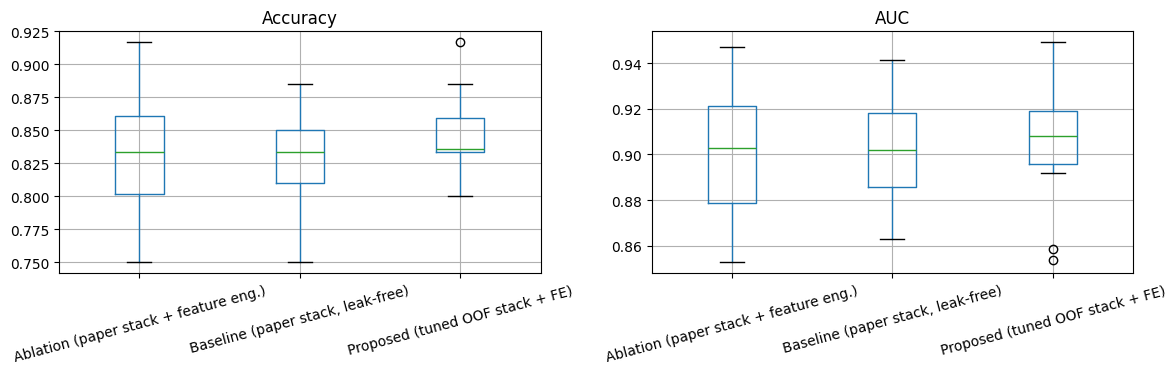

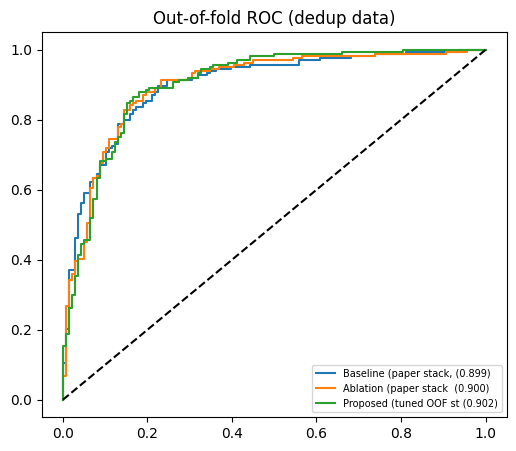

,Accuracy,Precision,Recall,F1,AUC
Paper (reported),0.9853,1.0000,0.9727,0.9861,0.9880
"Part1 repro, full data (20 seeds)",0.9956,0.9942,0.9972,0.9957,0.9997
"Part1 repro, deduplicated (20 seeds)",0.8254,0.8307,0.8592,0.8426,0.9071
"Baseline (paper stack, leak-free)",0.8277,0.8272,0.8722,0.8456,0.9015
Ablation (paper stack + feature eng.),0.8322,0.8320,0.8720,0.8489,0.9022
Proposed (tuned OOF stack + FE),0.8455,0.8395,0.8882,0.8614,0.9059


In [7]:
M = COLS + ["Specificity", "MCC"]
summ = cv_res.groupby("Model")[M].agg(["mean", "std"]).round(4); display(summ)
summ.to_csv("results/part2_summary.csv")

def corrected_t(d, n_tr, n_te):   # Nadeau & Bengio corrected resampled t-test
    k = len(d); tt = d.mean() / np.sqrt((1/k + n_te/n_tr) * d.var(ddof=1))
    return tt, 2 * tdist.sf(abs(tt), k - 1)

n = len(df_u); stats = []
b = cv_res[cv_res.Model == B].sort_values("fold")
for other in [A, P]:
    o = cv_res[cv_res.Model == other].sort_values("fold")
    for m in ["Accuracy", "F1", "AUC"]:
        d = (o[m].values - b[m].values)
        _, pw = wilcoxon(d) if np.any(d != 0) else (0, 1.0)
        _, pt = corrected_t(d, .8*n, .2*n)
        stats.append(dict(Model=other, Metric=m, MeanDiff=d.mean(), Wilcoxon_p=pw, CorrectedT_p=pt))
display(pd.DataFrame(stats).round(4)); pd.DataFrame(stats).to_csv("results/part2_stats.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, m in zip(ax, ["Accuracy", "AUC"]):
    cv_res.boxplot(column=m, by="Model", ax=a, rot=15); a.set_title(m); a.set_xlabel("")
plt.suptitle(""); plt.tight_layout(); plt.savefig("results/p2_boxplots.png", dpi=150); plt.show()

plt.figure(figsize=(6, 5))
for nm in MODELS:
    f, t_, _ = roc_curve(yu, oof[nm]); plt.plot(f, t_, label=f"{nm[:22]} ({roc_auc_score(yu, oof[nm]):.3f})")
plt.plot([0, 1], [0, 1], "k--"); plt.legend(fontsize=7); plt.title("Out-of-fold ROC (dedup data)")
plt.savefig("results/p2_roc.png", dpi=150); plt.show()

# Final comparison: paper vs Part 1 vs Part 2
S = lambda d: d[d.Model == "Stacking"][COLS].mean().to_dict()
cm_ = lambda name: cv_res[cv_res.Model == name][COLS].mean().to_dict()
final = pd.DataFrame({"Paper (reported)": PAPER["Stacking"],
                      "Part1 repro, full data (20 seeds)": S(full_runs),
                      "Part1 repro, deduplicated (20 seeds)": S(dedup_runs),
                      B: cm_(B), A: cm_(A), P: cm_(P)}).T.round(4)
display(final); final.to_csv("results/final_comparison.csv")